For this project, we progressed across three variations of the dataset - however this demo only shows the result for the top performing models from the Aug - 15 version. Please upload the saved model files from the "Saved Models" folder to ensure the code runs smoothly.

# Imports

In [ ]:
import pandas as pd
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
import numpy as np
from collections import defaultdict
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures
nltk.download('punkt')
nltk.download('punkt_tab')
from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Loading Data

In [ ]:
# load all three datasets
# raw data
df_raw = pd.read_csv('./mtsamples.csv')
# augumented w/ 20
df_20 = pd.read_csv('mtsamples_augmented.csv')
# augumented w/ 15
df_15 = pd.read_csv('./augmented_mtsamples.csv')

In [ ]:
# Checks to see that the data was loaded correctly by printing the dataframe.
# Takes in a dataframe and a string (for the header), prints out the number of
# rows, the number of columns, the column names, and the first row.
def check_data(df, name):
  print(f"\n{name}")
  print("Number of rows:", len(df))
  print("Number of columns:", len(df.columns))
  print("Columns:", df.columns.tolist())

  print("\nFirst row in the file:")
  display(df.head(1))

check_data(df_raw, "Raw")
check_data(df_20, "Augumented 20")
check_data(df_15, "Augumented 15")



Raw
Number of rows: 4999
Number of columns: 6
Columns: ['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

First row in the file:


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."



Augumented 20
Number of rows: 7530
Number of columns: 7
Columns: ['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords', 'processed_data', 'label']

First row in the file:


,description,medical_specialty,sample_name,transcription,keywords,processed_data,label
0,"Bilateral myringotomies, insertion of PE tube...",Surgery,Myringotomy/Tube Insertion,"PREOPERATIVE DIAGNOSES:, Chronic otitis media...","surgery, bilateral myringotomies, insertion of...",preoperative diagnose chronic otitis media eff...,18



Augumented 15
Number of rows: 5436
Number of columns: 7
Columns: ['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords', 'processed_data', 'label']

First row in the file:


,description,medical_specialty,sample_name,transcription,keywords,processed_data,label
0,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple...",mode atrial enlargement atrial diameter cm siz...,0


# Preprocessing
The following consists of multiple processes on making the TF-IDF more medical jargon oriented.

## Medical Aware Tokenization

In [ ]:
# A custom medically oriented tokenizer that preserves relevant formating such as
# medical codes, dosages, and vitals. It takes in string and returns a list of
#tokens
class medical_tokenizer:
  def __init__(self):
    self.patterns = { 'med_codes': r'\b[A-Z]\d{2}\.?\d*\b',
                      'dosage': r'\b\d+\s*(?:mg|mcg|ml|units?)\b',
                      'vitals':r'\b(?:bp|hr|rr|spo2|temp)\s*:?\s*[\d/]+',
                     }
  # Takes and preserves the medical pattern tokens from text. It takes in a string
  # and returns a list of tokens and placeholder tags (for medical patterns)
  def tokenize(self, text):
    processed = str(text)
    preserved = []
    for name, pattern in self.patterns.items():
      for match in re.finditer(pattern, processed, re.IGNORECASE):
        token = f"MED_{name.upper()}_{len(preserved)}"
        preserved.append((token, match.group()))
        processed = processed.replace(match.group(), f" {token} ", 1)
    standard_tokens = re.findall(r'\b\w+\b', processed.lower())
    return standard_tokens + [p[0] for p in preserved]

# medical phrases that are present that should be preserved as a single token
medical_phrases = { 'myocardial infarction', 'left ventricular', 'atrial fibrillation',
                    'coronary artery', 'heart failure', 'multiple sclerosis',
                    'cerebral infarction', 'spinal cord', 'range of motion',
                    'total knee', 'rotator cuff', 'blood pressure', 'heart rate',
                    'shortness of breath', 'chest pain', 'abdominal pain',
                    'physical therapy'
                  }

# medical stopwords that don't help with classification
medical_stop = { 'patient', 'history', 'procedure', 'noted', 'performed',
                  'presented', 'diagnosis', 'treatment', 'follow', 'placed'
                }

# Joins medical phrases by grouping them into a single token. Takes in a lowercase
# string and returns aforementioned text as a single string (joined by _).
def enhance_medical_phrases(text):
  for phrase in medical_phrases:
    text = re.sub(re.escape(phrase), phrase.replace(' ', '_'), text, flags=re.IGNORECASE)
  return text

tokenizer = medical_tokenizer()
lemmatizer = WordNetLemmatizer()
stop_words =  set(stopwords.words('english')) | medical_stop

# Cleans and normalizes data. Takes in a string and returns a cleaned string
# or '' if the original string was empty.
def data_preprocessing(data):
  if pd.isna(data):
    return ''
  data = data.lower()
  data = re.sub(r"[^a-z\s]", " ", data)
  tokens = data.split()
  tokens = [t for t in tokens if t not in stop_words]
  tokens = [lemmatizer.lemmatize(t) for t in tokens]
  tokens = tokens + tokenizer.tokenize(data)
  text = " ".join(tokens)
  text = enhance_medical_phrases(text)
  return text


##  Domain-Specific IDF Calculation

In [ ]:
# medical domain specific boost

#increase the weight of specific terms (indicate classification)
medical_boosted_terms = { 'myocardial', 'ejection', 'stenosis', 'arrhythmia', 'pericardial',
                        'cerebrospinal', 'seizure', 'encephalopathy', 'cortical',
                        'arthroplasty', 'fracture', 'ligament', 'meniscus',
                        'biopsy', 'laparoscopic', 'metastatic', 'dialysis', 'endoscopy'
                      }

# Appends the preprocessed description and keywords to the corresponding
# processed data row. Takes in a row from a datafram and returns a combined
# string
def boost_keywords(row):
  extra = []
  if pd.notna(row['description']):
      extra.append(data_preprocessing(row['description']))
  if pd.notna(row['keywords']):
      extra.append(enhance_medical_phrases(row['keywords'].lower()))
  return row['processed_data'] + ' ' + ' '.join(extra)


## Bigram Enhancement

In [ ]:
# bigram finder

# Finds significant two word medical phrases in the dataset using PMI scoring.
# Takes in a dataframe and returns a set of paired tuples.
def get_bigrams(df):
  # medical required words (as least one) in a bigram
  medical_required_words = { 'cardiac', 'renal', 'hepatic', 'pulmonary', 'ventricular', 'atrial',
                            'arterial', 'spinal', 'cerebral', 'coronary', 'aortic', 'mitral',
                            'thyroid', 'diabetes', 'hypertension', 'fracture', 'tumor', 'lesion',
                            'biopsy', 'stenosis', 'fibrillation', 'infarction', 'hemorrhage',
                            'edema', 'necrosis', 'carcinoma', 'malignant', 'benign', 'metastatic'
                          }
  # combine all processed text and find bigrams
  all_text = ' '.join(df['processed_data'].tolist())
  tokens = all_text.split()

  bigram_finder = BigramCollocationFinder.from_words(tokens)
  bigram_finder.apply_freq_filter(20)

  pmi_bigrams = bigram_finder.score_ngrams(BigramAssocMeasures.pmi)

  # keep only high-scoring bigrams
  sig_threshold = 8.0
  sig_bigrams = { bigram for bigram, score in pmi_bigrams
                  if score > sig_threshold
                  and any(word in medical_required_words for word in bigram)
                }
  return sig_bigrams

In [ ]:
# bigram enhancer

# Joins paired bigrams by grouping them into a single token. Takes in a set of
# bigram tuples and a string, and returns the merged string
def preprocess_with_bigrams(sig_bigrams, text):
  tokens = text.split()
  processed_tokens = []
  i = 0
  while i < len(tokens):
    if i < len(tokens) - 1:
      bigram = (tokens[i], tokens[i+1])
      if bigram in sig_bigrams:
        processed_tokens.append('_'.join(bigram))
        i += 2
        continue
    processed_tokens.append(tokens[i])
    i += 1
  return ' '.join(processed_tokens)


In [ ]:
# Automate the entire preprocessing process on a dataframe. Takes in a dataframe
# and returns a cleaned one.
def prepare_df(df):
  df = df.copy()

  # drop rows without a transcription
  df = df.dropna(subset=['transcription'])
  df['medical_specialty'] = df['medical_specialty'].str.strip()

  # raw dataset needs min 150
  if 'label' not in df.columns:
    counts = df['medical_specialty'].value_counts()
    df = df[df['medical_specialty'].isin(counts[counts >= 150].index)]

  # label encode medical_specialty
  label_encoder = LabelEncoder()
  df['label'] = label_encoder.fit_transform(df['medical_specialty'])

  # preprocess transcription text
  print("  Applying data_preprocessing")
  df['processed_data'] = df['transcription'].apply(data_preprocessing)

  # boost with description + keywords
  print("  Applying boost_keywords")
  df['processed_data'] = df.apply(boost_keywords, axis=1)

  # bigram enhancement
  print("  Applying get_bigrams")
  sig_bigrams = get_bigrams(df)
  df['processed_data'] = df['processed_data'].apply(
      lambda t: preprocess_with_bigrams(sig_bigrams, t)
  )

  return df, label_encoder

## Split Data

In [ ]:
#split testing and training sets -old code before swithcing to gss
#from sklearn.model_selection import train_test_split

#x_train, x_test, y_train, y_test = train_test_split(
    #df['processed_data'], df['label'],
    #test_size=0.2, random_state=42, stratify=df['label']
#)


In [ ]:
# Split the dataset into a 80/10/10 split for training, testing, and validation
# respectively. Takes in a datagram and returns three different splits.
def split_set(df) :
  # split training and test + validation data (80/20)
  gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
  train_idx, temp_idx = next(gss1.split(df, groups=df["processed_data"]))

  train_df = df.iloc[train_idx]
  temp_df  = df.iloc[temp_idx]

  # split validation and test data (10/10)
  gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
  val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["processed_data"]))

  # group identical transcriptions
  val_df  = temp_df.iloc[val_idx]
  test_df = temp_df.iloc[test_idx]

  #extract text + labels
  x_train, y_train = train_df["processed_data"], train_df["label"]
  x_val,   y_val   = val_df["processed_data"],   val_df["label"]
  x_test,  y_test  = test_df["processed_data"],  test_df["label"]

  return (train_df, val_df, test_df, x_train, y_train,
          x_val, y_val, x_test, y_test)

# Additional Helper Functions

In [ ]:
# A consolidated confusion matrix plotting function that prints out a classification
# report and a confusion matrix. Takes in y true predicted labels, a label encoder,
# and a title
def plot_confusion_matrix(y_true, y_pred, label_encoder, title):
    numeric_labels = sorted(y_true.unique())
    string_labels = [label_encoder.classes_[i] for i in numeric_labels]

    print(f"\n{title}:")
    print(classification_report(y_true, y_pred, target_names=string_labels, zero_division=0))

    conf_mat = confusion_matrix(y_true, y_pred, labels=numeric_labels, normalize = 'true')
    plt.figure(figsize=(15, 10))
    sns.heatmap(conf_mat,
                annot=True,
                cmap="Blues",
                fmt=".2f",
                xticklabels=string_labels,
                yticklabels=string_labels)
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

 # Finds the best C value for the LR and SVM models using cross validation. Takes
 # in training text and labels and returns a dictionary of the best C values.
def best_C(x_train, y_train):
  C_values = [0.1, 0.5, 1.0]
  classifiers = {'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
                'LinearSVC': LinearSVC(max_iter=2000,class_weight='balanced'),
                }
  # keep the best c per classifier
  best_C = {}

  #for each classifier
  for clf_name, clf in classifiers.items():
    print(f"\n  {clf_name}:")
    best_score, best_c_val = -1, 1.0
    #test each c
    for C in C_values:
      clf.set_params(C=C)
      pipeline = Pipeline([
                ('tfidf', TfidfVectorizer(max_features=50000,
                                          ngram_range=(1, 2),
                                          min_df=2,
                                          sublinear_tf=True)),
                ('clf', clf),
            ])
      #cross validate
      scores = cross_val_score(pipeline, x_train, y_train,
                               cv=5, scoring='accuracy', n_jobs=-1)

      print(f"    C={C}: mean={scores.mean():.4f}, std={scores.std():.4f}")
      if scores.mean() > best_score:
        best_score, best_c_val = scores.mean(), C
    best_C[clf_name] = best_c_val

    print(f"      Best C for {clf_name}: {best_c_val}  (acc={best_score:.4f})")

  #final c selected per model
  print(f"  Finished Applying best_C: LR best C={best_C['Logistic Regression']}, SVC best C={best_C['LinearSVC']}")
  return best_C




#Results

Results for Augmented-15 (augmented_mtsamples.csv): 
  Applying data_preprocessing
  Applying boost_keywords
  Applying get_bigrams

  Logistic Regression:
    C=0.1: mean=0.7550, std=0.0136
    C=0.5: mean=0.8063, std=0.0153
    C=1.0: mean=0.8271, std=0.0127
      Best C for Logistic Regression: 1.0  (acc=0.8271)

  LinearSVC:
    C=0.1: mean=0.8410, std=0.0153
    C=0.5: mean=0.8563, std=0.0151
    C=1.0: mean=0.8596, std=0.0187
      Best C for LinearSVC: 1.0  (acc=0.8596)
  Finished Applying best_C: LR best C=1.0, SVC best C=1.0

  Logistic Regression Accuracy: 0.7622
  Linear SVC Accuracy:          0.7570

Augmented-15 (augmented_mtsamples.csv) + Logistic Regression (C=1.0):
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.89      0.83      0.86        76
      ENT - Otolaryngology       0.89      0.83      0.86        30
    Emergency Room Reports       0.62      0.85      0.72        34
          Gastroenterology       0.85

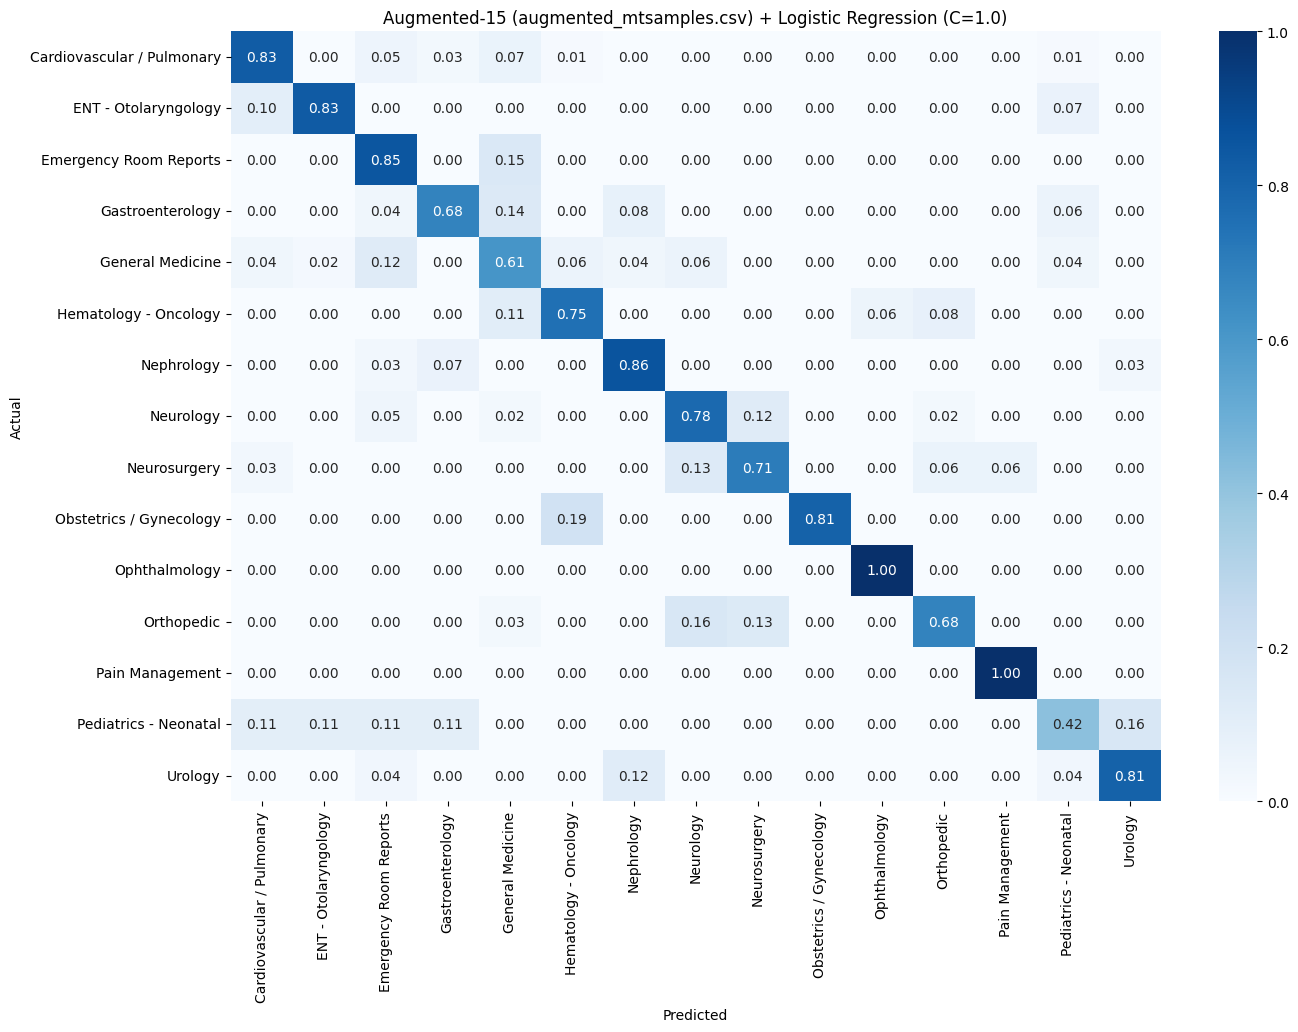


Augmented-15 (augmented_mtsamples.csv) + Linear SVC (C=1.0):
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.90      0.87      0.89        76
      ENT - Otolaryngology       0.86      0.83      0.85        30
    Emergency Room Reports       0.59      0.71      0.64        34
          Gastroenterology       0.83      0.76      0.79        50
          General Medicine       0.70      0.57      0.63        49
     Hematology - Oncology       0.76      0.78      0.77        36
                Nephrology       0.71      0.69      0.70        29
                 Neurology       0.58      0.73      0.65        41
              Neurosurgery       0.50      0.45      0.47        31
   Obstetrics / Gynecology       0.97      0.83      0.90        36
             Ophthalmology       0.90      1.00      0.95        18
                Orthopedic       0.77      0.71      0.74        75
           Pain Management       0.92      1.00      

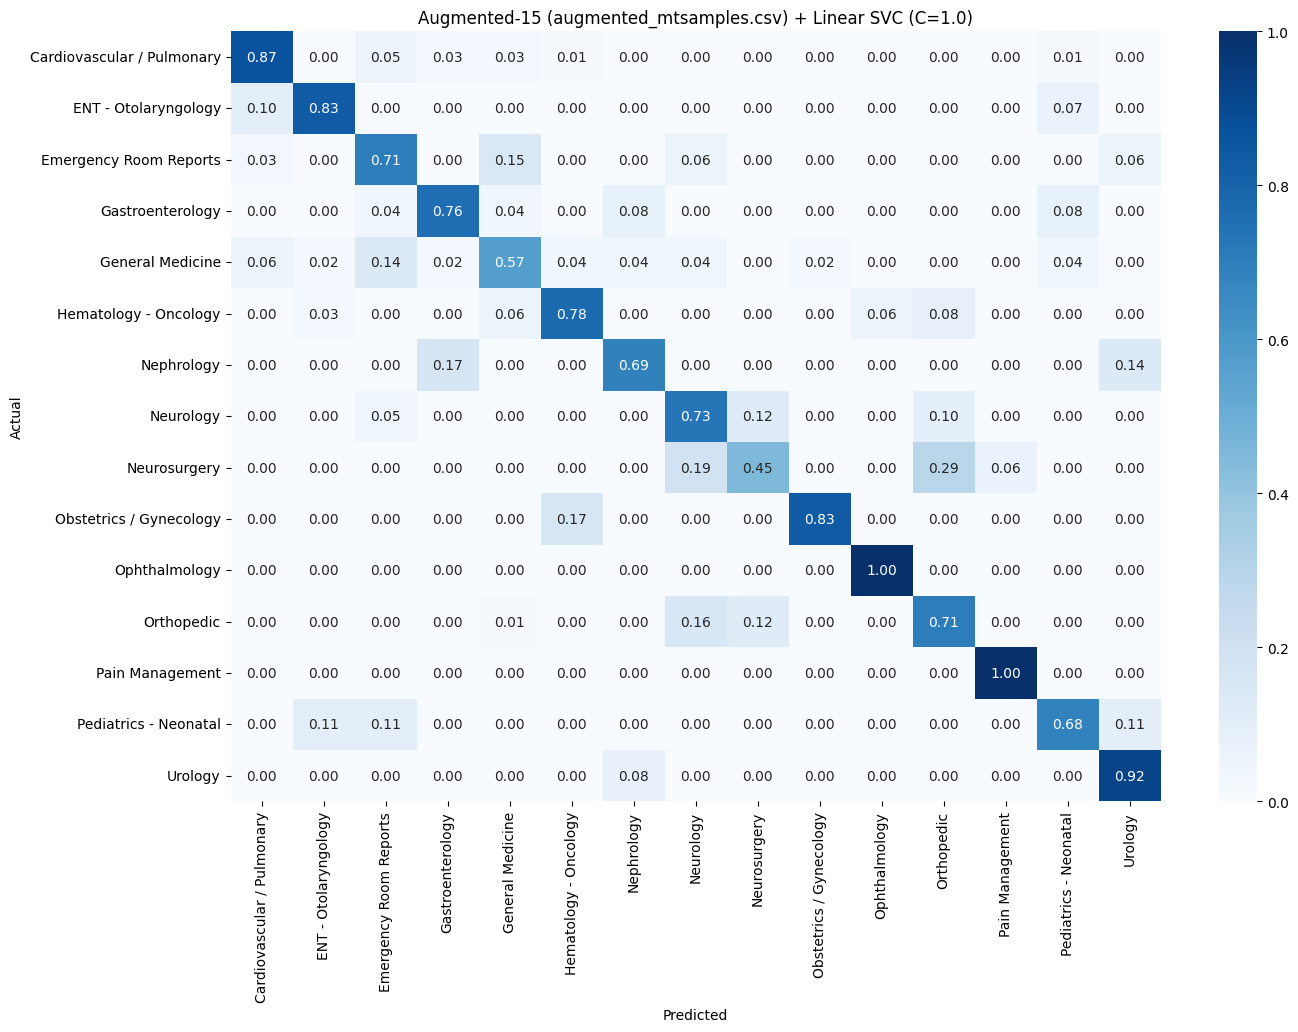

In [ ]:
# Automate the entire TF-IDF process for a single dataset. Takes in a dataframe
# and a string (name of the dataset) and returns artefacts.
def run_tfidf(df, dataset):
  print(f"Results for {dataset}: ")

  #preprocessing
  df_processed, label_encoder = prepare_df(df)

  # split training, testing, and validation sets
  (train_df, val_df, test_df, x_train, y_train, x_val, y_val,
   x_test,  y_test) = split_set(df_processed)

  # train tfidf
  # fine tune it to improve performance
  tfidfVectorizer = TfidfVectorizer(max_features=50000,
                                    ngram_range=(1, 2),
                                    min_df=2,
                                    sublinear_tf=True)

  #train on training data and convert to numeric data
  xTrain = tfidfVectorizer.fit_transform(x_train)
  # convert to numeric data based on training data
  xTest = tfidfVectorizer.transform(x_test)

  #make sure they have the corresponding labels
  yTrain = y_train
  yTest = y_test

  # find the best c
  pick_C = best_C(x_train, y_train)

  # train the corresponding model

  #lr
  c_lr = pick_C['Logistic Regression']
  LR_Classifier = LogisticRegression(max_iter=1000, class_weight='balanced',
                                       C=c_lr)
  LR_Classifier.fit(xTrain, yTrain)

  lr_preds = LR_Classifier.predict(xTest)
  print(f"\n  Logistic Regression Accuracy: {LR_Classifier.score(xTest, yTest):.4f}")

  # svm
  c_svm = pick_C['LinearSVC']
  SVM_Classifier = LinearSVC(max_iter=2000, class_weight='balanced',
                                C=c_svm)
  SVM_Classifier.fit(xTrain, yTrain)

  svm_preds = SVM_Classifier.predict(xTest)
  print(f"  Linear SVC Accuracy:          {SVM_Classifier.score(xTest, yTest):.4f}")

  # evaluate
  plot_confusion_matrix(yTest, lr_preds,  label_encoder,
                        f"{dataset} + Logistic Regression (C={c_lr})")
  plot_confusion_matrix(yTest, svm_preds, label_encoder,
                        f"{dataset} + Linear SVC (C={c_svm})")

  # return artefacts
  return {'vectorizer':tfidfVectorizer,
         'lr': LR_Classifier,
         'svm': SVM_Classifier,
         'label_encoder': label_encoder,
         'x_test':x_test.tolist(),
          'y_test': y_test.tolist(),
          }


# run
results_raw = run_tfidf(df_raw, "Raw (mtsamples.csv)")
results_20  = run_tfidf(df_20,  "Augmented-20 (mtsamples_augmented.csv)")
results_15  = run_tfidf(df_15,  "Augmented-15 (augmented_mtsamples.csv)")



Save the models for demo.py

In [ ]:
from google.colab import files
import pickle

with open("tfidf_augmented_15.pkl", "wb") as f:
  pickle.dump(results_15, f)

files.download("tfidf_augmented_15.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>